#### 1. Import Libraries

In [41]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#### 2.Data Collecting

In [42]:
df = pd.read_csv("../data/raw/amazon_sales_dataset.csv")

#### 3.Data Understanding

In [43]:
df.shape

(50000, 13)

In [44]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='str')

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             49998 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   49996 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            49997 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 6.6 MB


#### 4.Data Validation

In [46]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               2
discount_percent    0
quantity_sold       0
customer_region     4
payment_method      0
rating              3
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

#### 5.Fill Missing Values 

In [48]:
df['price'] = df['price'].fillna(df['price']).mean()
df['rating'] = df['rating'].fillna(df['rating']).mean()
df['customer_region'] = df['customer_region'].fillna(df['customer_region'].mode()[0])

#### 6.Handaling Missing Values

In [49]:
 df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

#### 7.Removing Duplicates

In [50]:
df.drop_duplicates()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,4/13/2022,2637,Books,252.508305,10,4,North America,UPI,2.996278,443,115.88,463.52
1,2,3/12/2023,2300,Fashion,252.508305,20,5,Asia,Credit Card,2.996278,475,242.08,1210.40
2,3,9/28/2022,3670,Sports,252.508305,20,2,Europe,UPI,2.996278,183,396.64,793.28
3,4,4/17/2022,2522,Books,252.508305,15,4,Middle East,UPI,2.996278,212,316.16,1264.64
4,5,3/13/2022,1717,Beauty,252.508305,0,4,Middle East,UPI,2.996278,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,9/3/2022,1433,Beauty,252.508305,0,5,Middle East,Credit Card,2.996278,386,26.99,134.95
49996,49997,7/3/2022,1428,Beauty,252.508305,10,5,Asia,Credit Card,2.996278,8,264.81,1324.05
49997,49998,2/17/2023,4651,Electronics,252.508305,30,4,Asia,Debit Card,2.996278,104,246.48,985.92
49998,49999,9/30/2022,4371,Beauty,252.508305,5,1,Middle East,UPI,2.996278,316,292.16,292.16


#### 8.Data Type Conversion

In [51]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [52]:
df.dtypes

order_id                     int64
order_date          datetime64[us]
product_id                   int64
product_category               str
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region                str
payment_method                 str
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object

#### 9.Data Standardization

In [53]:
df.columns.str.strip()

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='str')

#### 10.Outlier Detection

In [54]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers(df, 'price')
df = remove_outliers(df, 'total_revenue')
df = remove_outliers(df, 'discounted_price')


#### 11.Feature Engineering

In [55]:
df['profit_estimate'] = df['total_revenue']-(df['price']*df['quantity_sold'])
df['day_of_week'] = df['order_date'].dt.day_name()
df['month'] = df['order_date'].dt.to_period('M')

#### 12.Basic Statistical Analysis

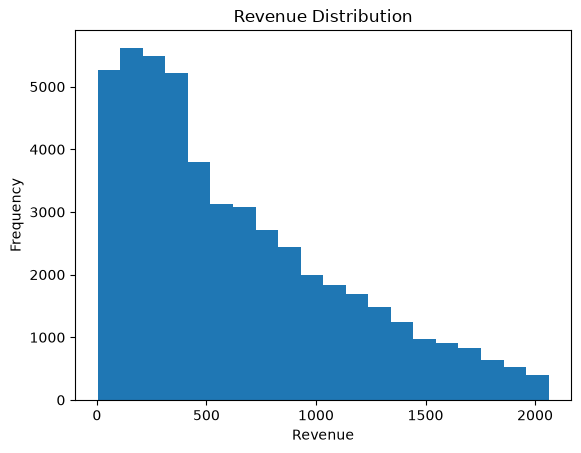

In [56]:
plt.hist(df['total_revenue'], bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

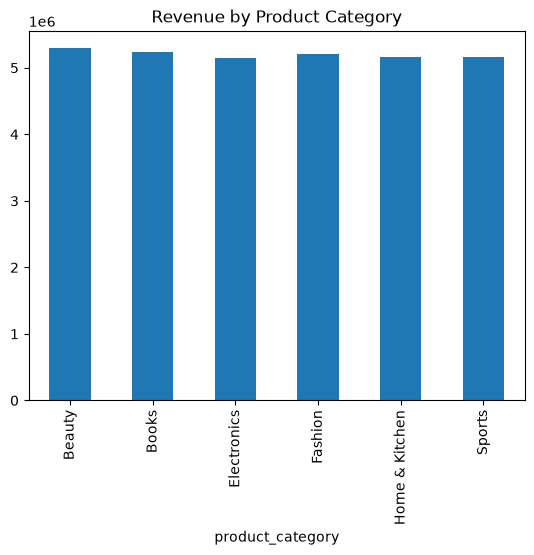

In [57]:
df.groupby('product_category')['total_revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product Category")
plt.show()

#### 13.Correlation Analysis

In [58]:
corr =df[['price', 'quantity_sold', 'discount_percent', 'total_revenue']].corr()

print(corr)

                  price  quantity_sold  discount_percent  total_revenue
price               NaN            NaN               NaN            NaN
quantity_sold       NaN       1.000000          0.021076       0.579197
discount_percent    NaN       0.021076          1.000000      -0.112028
total_revenue       NaN       0.579197         -0.112028       1.000000


#### 13.Grouping

In [59]:
region_sales = df.groupby('customer_region')['total_revenue'].sum()
region_sales

customer_region
Asia             7777909.62
Europe           7729003.02
Middle East      7850489.32
North America    7840939.78
Name: total_revenue, dtype: float64

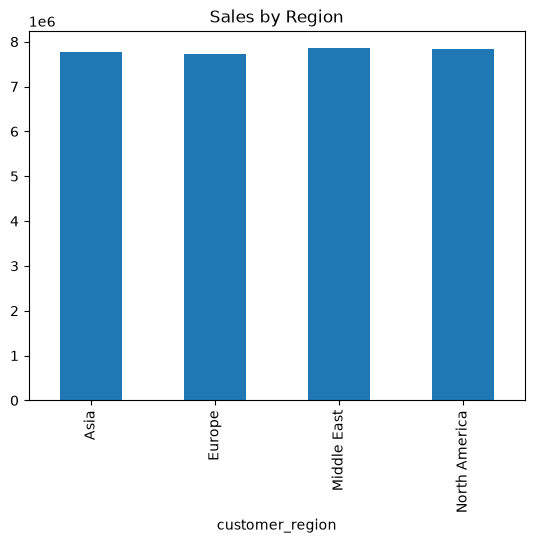

In [60]:
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

#### 14.Time Series Analysis

In [61]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')

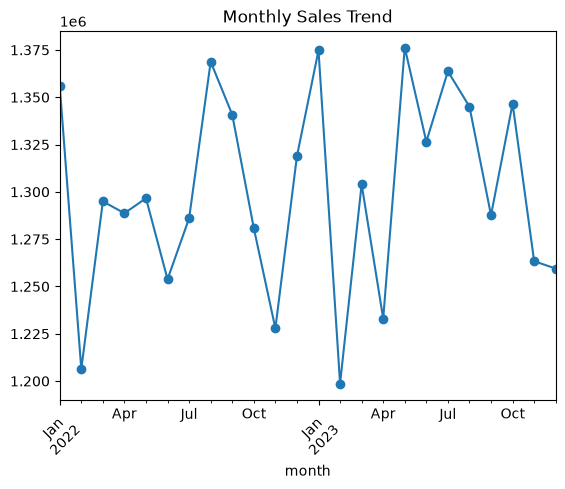

In [62]:
monthly_sales = df.groupby('month')['total_revenue'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

#### 15.Simple Prediction

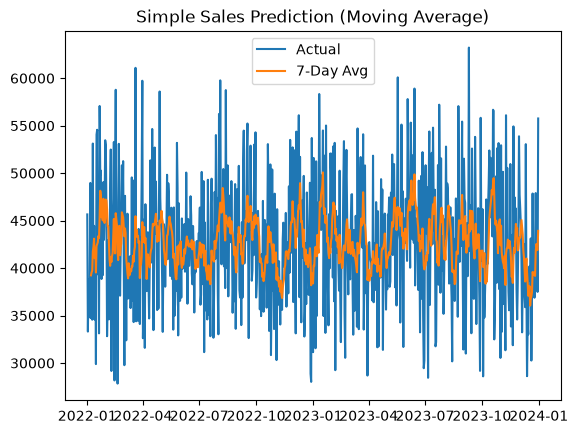

In [63]:
df_sorted = df.sort_values('order_date')
daily_sales = df_sorted.groupby('order_date')['total_revenue'].sum()

rolling_mean = daily_sales.rolling(window=7).mean()

plt.plot(daily_sales.index, daily_sales.values, label="Actual")
plt.plot(rolling_mean.index, rolling_mean.values, label="7-Day Avg")
plt.legend()
plt.title("Simple Sales Prediction (Moving Average)")
plt.show()

#### 16. Automate Data Cleaning

In [64]:
def clean_data(df):
    df = df.dropna()
    df = df.drop_duplicates()
    df['order_date'] = pd.to_datetime(df['order_date'])
    return df

df = clean_data(df)

#### 17.Business Insights Generation

In [65]:
top_category = df.groupby('product_category')['total_revenue'].sum().idxmax()
top_region = df.groupby('customer_region')['total_revenue'].sum().idxmax()

print("Top Category:", top_category)
print("Top Region:", top_region)

Top Category: Beauty
Top Region: Middle East


#### 18.Business Recommendations

In [66]:
print("Recommendation 1: Focus marketing on", top_category)
print("Recommendation 2: Expand delivery in", top_region)
print("Recommendation 3: Optimize discount strategy for high-sales categories")

Recommendation 1: Focus marketing on Beauty
Recommendation 2: Expand delivery in Middle East
Recommendation 3: Optimize discount strategy for high-sales categories


#### 19.Export Clean Dataset

In [67]:
df.to_csv("../data/processed/cleaned_ecommerce_data.csv", index=False)